In [16]:
import pandas as pd
import numpy as np


## ***LLM ratings***
Each of the 120 PolitiFact statements received exactly one rating from the LLM.

### 1.) ***S3***

In [17]:
llm_ratings_s3 = pd.read_csv("../data/llm_ratings_truth_s3_gpt-4o-mini.csv")

# missing data?
print(f"Missing data in LLM Ratings: {llm_ratings_s3.isnull().sum().sum()}")

#shape
print(f"LLM Ratings shape: {llm_ratings_s3.shape}")

llm_ratings_s3.head()

Missing data in LLM Ratings: 0
LLM Ratings shape: (120, 2)


,statement,rating
0,22 times Barack Obama said he did not have the...,1.0
1,6400 Ohioans lost manufacturing jobs in the m...,2.0
2,98 percent of small businesses make less than ...,1.0
3,A recent economic uptick appears to coincide w...,1.0
4,According to Wikipedia there are only five cou...,1.0


### 2.) ***S6***

In [18]:
llm_ratings_s6 = pd.read_csv("../data/llm_ratings_truth_s6_gpt-4o-mini.csv")

# missing data?
print(f"Missing data in LLM Ratings: {llm_ratings_s3.isnull().sum().sum()}")

#shape
print(f"LLM Ratings shape: {llm_ratings_s6.shape}")

llm_ratings_s6.head()

Missing data in LLM Ratings: 0
LLM Ratings shape: (120, 2)


,statement,rating
0,22 times Barack Obama said he did not have the...,3.0
1,6400 Ohioans lost manufacturing jobs in the m...,4.0
2,98 percent of small businesses make less than ...,4.0
3,A recent economic uptick appears to coincide w...,3.0
4,According to Wikipedia there are only five cou...,2.0


## ***Human annotations***
- 120 statements × 55 columns (1 text + 54 human annotators).
- Each unit_x column corresponds to a unique crowd worker.
- The NaNs represent missing annotations — many workers didn’t rate all 120 statements.
- Some rows (like your row 1) have multiple non-NaN values → those are ratings from different annotators for that statement.

So this table mirrors the setup described in the paper — sparse crowd annotations where each statement is rated by only a subset of humans.

### 1.) ***S3***

In [19]:
human_judgments_s3 = pd.read_csv("../data/reliability_matrix_s3.csv")

# missing data?
print(f"Missing data in Human Judgments: {human_judgments_s3.isnull().sum().sum()}")

# shape
print(f"Human Judgments shape: {human_judgments_s3.shape}")

human_judgments_s3.head()

Missing data in Human Judgments: 6156
Human Judgments shape: (120, 55)


,statement,unit_0,unit_1,unit_10,unit_100,unit_101,unit_102,unit_103,unit_104,unit_105,...,unit_138,unit_139,unit_14,unit_140,unit_141,unit_142,unit_143,unit_144,unit_145,unit_146
0,22 times Barack Obama said he did not have the...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6400 Ohioans lost manufacturing jobs in the m...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2.0,NaN,1.0,NaN,2.0,NaN,2.0
2,98 percent of small businesses make less than ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A recent economic uptick appears to coincide w...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,According to Wikipedia there are only five cou...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.) ***S6***

In [20]:
human_judgments_s6 = pd.read_csv("../data/reliability_matrix_s6.csv")

# missing data?
print(f"Missing data in Human Judgments: {human_judgments_s6.isnull().sum().sum()}")

# shape
print(f"Human Judgments shape: {human_judgments_s6.shape}")

human_judgments_s6.head()

Missing data in Human Judgments: 3420
Human Judgments shape: (120, 31)


,statement,unit_0,unit_1,unit_10,unit_100,unit_101,unit_102,unit_103,unit_104,unit_105,...,unit_116,unit_117,unit_118,unit_119,unit_12,unit_120,unit_121,unit_122,unit_123,unit_124
0,22 times Barack Obama said he did not have the...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6400 Ohioans lost manufacturing jobs in the m...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,98 percent of small businesses make less than ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A recent economic uptick appears to coincide w...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,According to Wikipedia there are only five cou...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## ***Anaylsis***
### 2.) ***S3***

In [21]:
# rename rating to llm
llm_ratings_s3 = llm_ratings_s3.rename(columns={"rating": "GPT-4o mini"})

# rename unit_0 - unit_146 to human_#1 to human_#147
human_judgments_s3 = human_judgments_s3.rename(
    columns={f"unit_{i}":f"human_#{i+1}" for i in range(147)}
)

# merge on 'id'
merged_s3_df = pd.merge(llm_ratings_s3, human_judgments_s3, on="statement", how="inner")
# shape of merged df
print(f"Merged DataFrame shape: {merged_s3_df.shape}")

# gpt-4o-mini ratings unique values
print(f"Unique values in GPT-4o mini ratings: {merged_s3_df['GPT-4o mini'].unique()}")

# unique ratings across all human judges
human_cols = [c for c in merged_s3_df.columns if c.startswith("human_#")]
unique_human_ratings = np.unique(merged_s3_df[human_cols].values[~pd.isna(merged_s3_df[human_cols].values)])
print("Human rating scale:", unique_human_ratings)

merged_s3_df.head()

Merged DataFrame shape: (120, 56)
Unique values in GPT-4o mini ratings: [1. 2. 0.]
Human rating scale: [0. 1. 2.]


,statement,GPT-4o mini,human_#1,human_#2,human_#11,human_#101,human_#102,human_#103,human_#104,human_#105,...,human_#139,human_#140,human_#15,human_#141,human_#142,human_#143,human_#144,human_#145,human_#146,human_#147
0,22 times Barack Obama said he did not have the...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6400 Ohioans lost manufacturing jobs in the m...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2.0,NaN,1.0,NaN,2.0,NaN,2.0
2,98 percent of small businesses make less than ...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A recent economic uptick appears to coincide w...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,According to Wikipedia there are only five cou...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


✅ Found 54 valid human annotator columns.
✅ Keeping 48/120 rows with ≥2 human annotators.
✅ Added random judge baseline column: 'RANDOM_as_a_judge'


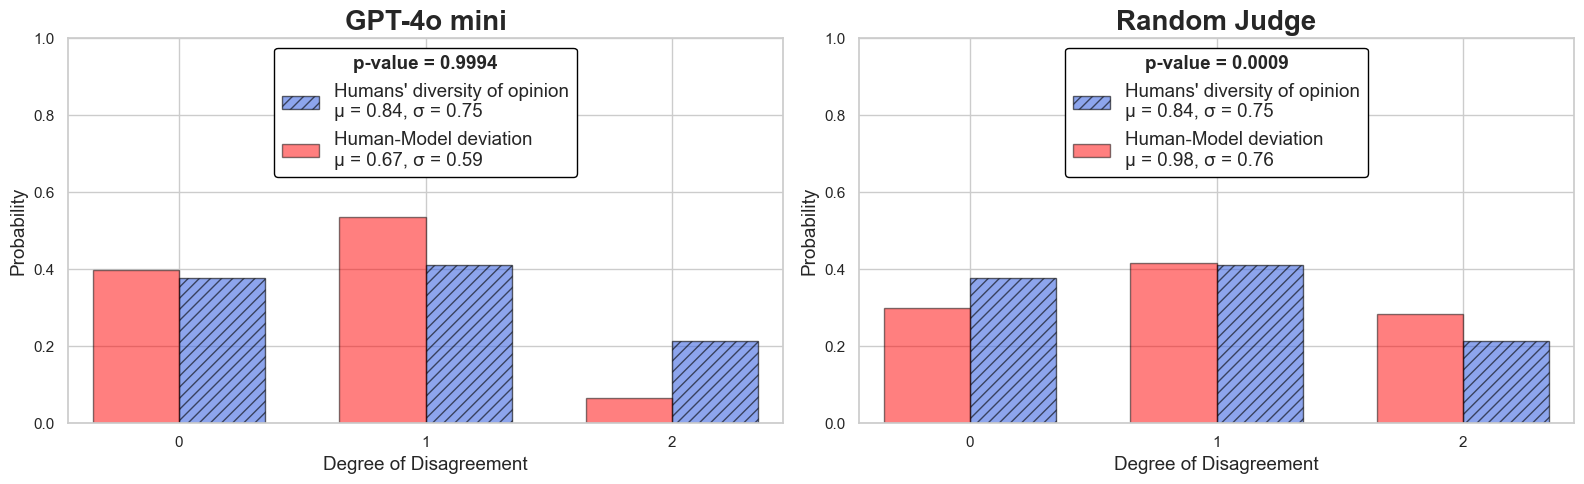

In [22]:
# Fix import path - add parent directory to Python path
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..', '..'))

from llm_good_enough import LLMGoodEnough

HUMAN_COLS = [c for c in merged_s3_df.columns if c.startswith("human_#")]
MIN, MAX = int(np.min(unique_human_ratings)), int(np.max(unique_human_ratings))

judge = LLMGoodEnough(
    df=merged_s3_df,
    human_cols=HUMAN_COLS,
    min_score=MIN, max_score=MAX
)

#  Compute disagreements for multiple models
model_disagreements = {
    "GPT-4o mini": judge.compute_llm_human_disagreements("GPT-4o mini"),
    "Random Judge": judge.compute_llm_human_disagreements("RANDOM_as_a_judge"),
}

# 5️Compute human-human baseline disagreements (optional but faster if reused)
human_disagreements = judge.compute_human_disagreements()

# 6Plot grid comparison
judge.plot_model_vs_human_grid(
    model_disagreement_dict=model_disagreements,
    human_human_disagreements=human_disagreements,
    y_lim=1,
    save_path=None  # or e.g., "results/model_grid.pdf"
)

### 2.) ***S6***

In [23]:
# rename rating to llm
llm_ratings_s6 = llm_ratings_s6.rename(columns={"rating": "GPT-4o mini"})

# rename unit_0 - unit_146 to human_#1 to human_#147
human_judgments_s6 = human_judgments_s6.rename(
    columns={f"unit_{i}":f"human_#{i+1}" for i in range(147)}
)

# merge on 'id'
merged_s6_df = pd.merge(llm_ratings_s6, human_judgments_s6, on="statement", how="inner")
# shape of merged df
print(f"Merged DataFrame shape: {merged_s6_df.shape}")

# gpt-4o-mini ratings unique values
print(f"Unique values in GPT-4o mini ratings: {merged_s6_df['GPT-4o mini'].unique()}")

# unique ratings across all human judges
human_cols = [c for c in merged_s6_df.columns if c.startswith("human_#")]
unique_human_ratings = np.unique(merged_s6_df[human_cols].values[~pd.isna(merged_s6_df[human_cols].values)])
print("Human rating scale:", unique_human_ratings)

merged_s6_df.head()

Merged DataFrame shape: (120, 32)
Unique values in GPT-4o mini ratings: [3. 4. 2. 1. 5.]
Human rating scale: [0. 1. 2. 3. 4. 5.]


,statement,GPT-4o mini,human_#1,human_#2,human_#11,human_#101,human_#102,human_#103,human_#104,human_#105,...,human_#117,human_#118,human_#119,human_#120,human_#13,human_#121,human_#122,human_#123,human_#124,human_#125
0,22 times Barack Obama said he did not have the...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6400 Ohioans lost manufacturing jobs in the m...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,98 percent of small businesses make less than ...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A recent economic uptick appears to coincide w...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,According to Wikipedia there are only five cou...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


✅ Found 30 valid human annotator columns.
✅ Keeping 36/120 rows with ≥2 human annotators.
✅ Added random judge baseline column: 'RANDOM_as_a_judge'


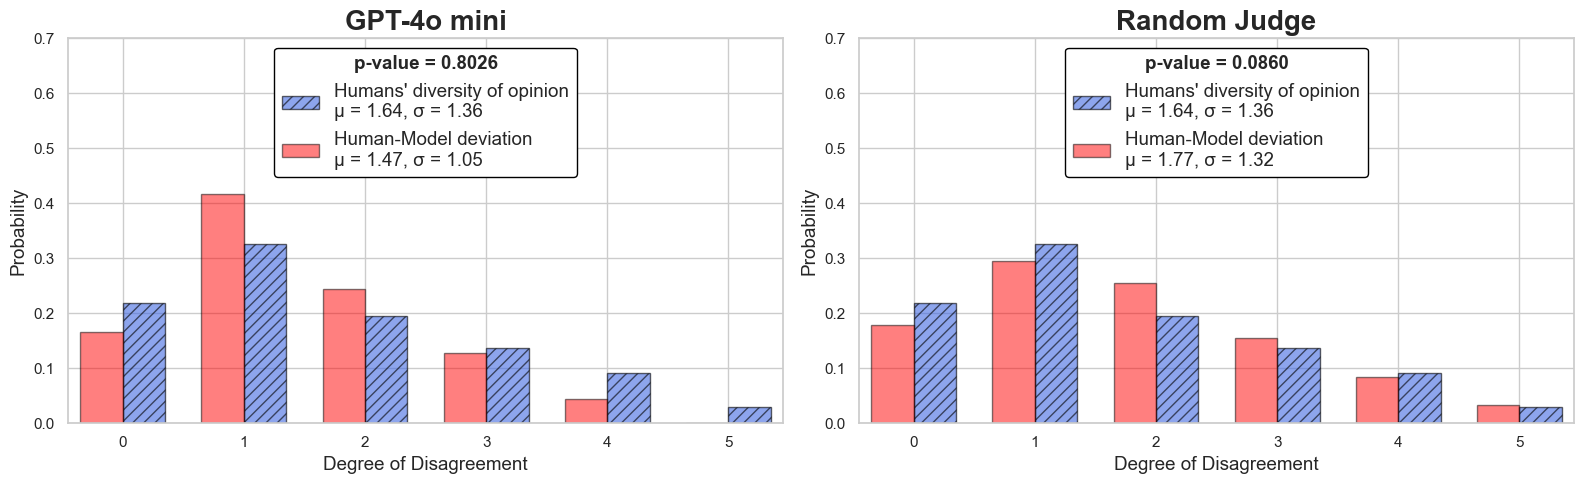

In [26]:
# Fix import path - add parent directory to Python path
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..', '..'))

from llm_good_enough import LLMGoodEnough

HUMAN_COLS = [c for c in merged_s6_df.columns if c.startswith("human_#")]
MIN, MAX = int(np.min(unique_human_ratings)), int(np.max(unique_human_ratings))

judge = LLMGoodEnough(
    df=merged_s6_df,
    human_cols=HUMAN_COLS,
    min_score=MIN, max_score=MAX
)

#  Compute disagreements for multiple models
model_disagreements = {
    "GPT-4o mini": judge.compute_llm_human_disagreements("GPT-4o mini"),
    "Random Judge": judge.compute_llm_human_disagreements("RANDOM_as_a_judge"),
}

# 5️Compute human-human baseline disagreements (optional but faster if reused)
human_disagreements = judge.compute_human_disagreements()

# 6Plot grid comparison
judge.plot_model_vs_human_grid(
    model_disagreement_dict=model_disagreements,
    human_human_disagreements=human_disagreements,
    y_lim=0.7,
    save_path=None  # or e.g., "results/model_grid.pdf"
)